In [2]:
#Dataset Overview
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/amazon.xlsx'

Mounted at /content/drive


In [4]:

df=pd.read_excel(path)
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [5]:
df.shape

(100000, 20)

In [6]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

In [8]:
df.describe()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


In [9]:
#KPI Analysis
#Total Sales
df['TotalAmount'].sum()

np.float64(91825647.92)

In [10]:
#Total Orders
df['OrderDate'].count()

np.int64(100000)

In [11]:
#Average Sales
df['TotalAmount'].mean()

np.float64(918.2564792000001)

In [12]:
#Maximum Quantite
df['Quantity'].max()

5

In [13]:
#Maximum Sales
df['TotalAmount'].max()

3534.98

In [14]:
#Minimum Sales
df['TotalAmount'].min()

4.27

In [15]:
#Revenue by State
df.groupby('State')['TotalAmount'].sum().sort_values(ascending=False)


,TotalAmount
State,
TX,22862540.54
CA,18231196.79
NC,4747701.73
WA,4660962.17
PA,4650673.88
CO,4638498.97
IL,4632847.44
OH,4615442.32
IN,4609048.43


In [16]:
#Revenue by Category
df.groupby('Category')['TotalAmount'].sum()

,TotalAmount
Category,
Books,15261837.01
Clothing,15253397.50
Electronics,15584217.18
Home & Kitchen,15163939.36
Sports & Outdoors,15345571.88
Toys & Games,15216684.99


In [17]:
#Top 5 Customers
df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head()

,TotalAmount
CustomerID,
CUST023748,15215.79
CUST009614,12160.96
CUST034178,11418.88
CUST001153,11282.96
CUST004883,11214.44


In [22]:
#Total quantity sold for each product
df.groupby('ProductID')['Quantity'].sum()

,Quantity
ProductID,
P00001,6008
P00002,5782
P00003,6060
P00004,5811
P00005,5992
P00006,6170
P00007,6161
P00008,6111
P00009,5996


In [18]:
#Order by Payment Mode
df.groupby('PaymentMethod')['OrderID'].count()

,OrderID
PaymentMethod,
Amazon Pay,15017
Cash on Delivery,4928
Credit Card,35038
Debit Card,20024
Net Banking,9927
UPI,15066


In [25]:
#Monthly sales
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['OrderMonth'] = df['OrderDate'].dt.to_period('M')

df.groupby('OrderMonth')['TotalAmount'].sum()

,TotalAmount
OrderMonth,
2020-01,1637069.40
2020-02,1339388.21
2020-03,1587125.66
2020-04,1588347.29
2020-05,1533834.17
2020-06,1500269.29
2020-07,1552981.94
2020-08,1640874.93
2020-09,1554682.21


In [27]:
#Sales by State for every Category
df.groupby(['State', 'Category'])['TotalAmount'].sum().reset_index()

,State,Category,TotalAmount
0,AZ,Books,793211.33
1,AZ,Clothing,691249.82
2,AZ,Electronics,747955.37
3,AZ,Home & Kitchen,737616.34
4,AZ,Sports & Outdoors,694318.06
...,...,...,...
73,WA,Clothing,747668.70
74,WA,Electronics,879580.90
75,WA,Home & Kitchen,809448.28
76,WA,Sports & Outdoors,807282.60


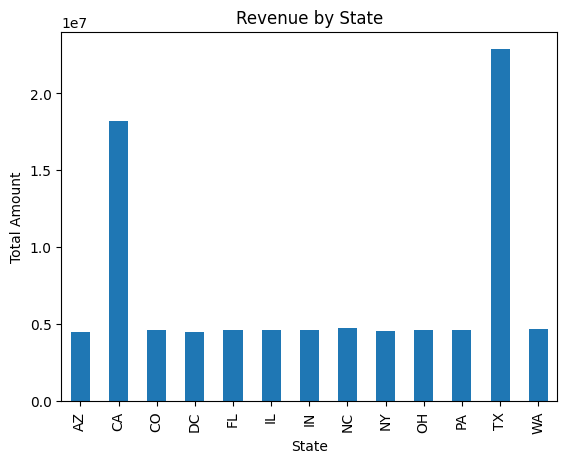

In [19]:
#Visualization
df.groupby('State')['TotalAmount'].sum().plot(kind='bar')
plt.title('Revenue by State')
plt.xlabel('State')
plt.ylabel('Total Amount')
plt.show()

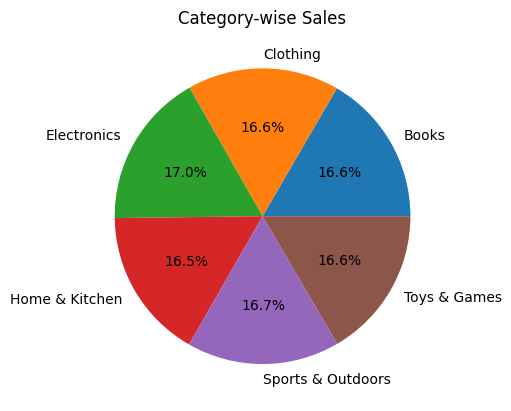

In [20]:
df.groupby('Category')['TotalAmount'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title('Category-wise Sales')
plt.ylabel('')
plt.show()

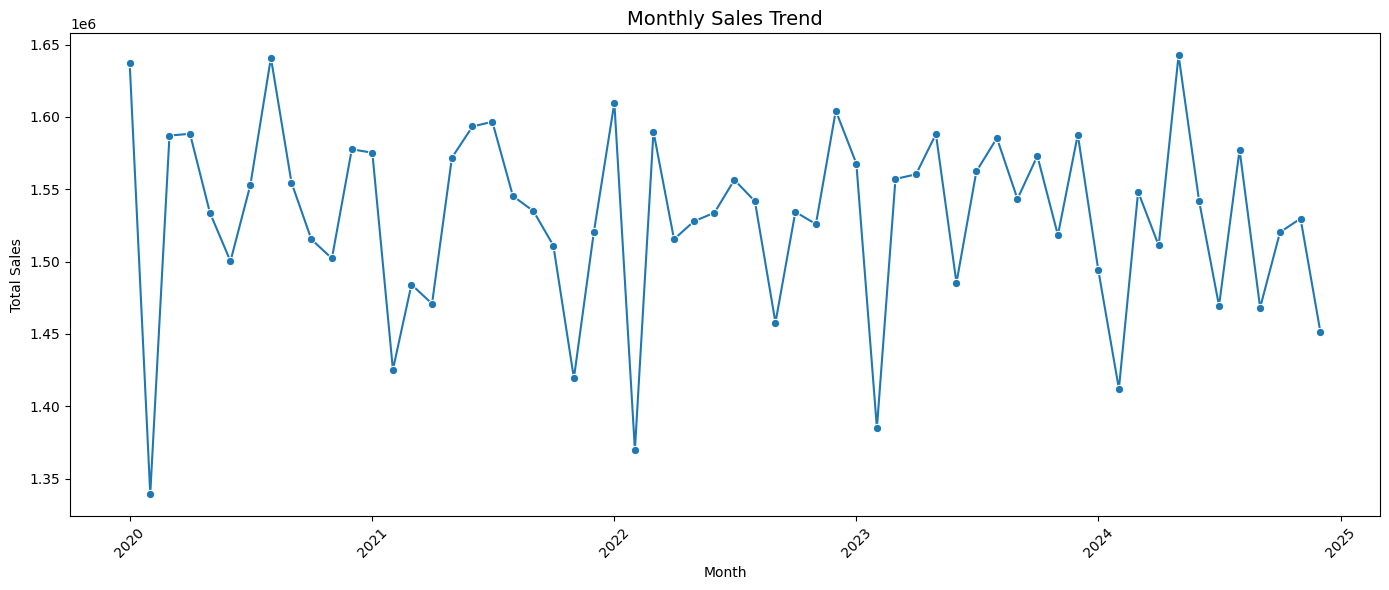

In [28]:
monthly_sales_ts = df.groupby('OrderMonth')['TotalAmount'].sum()
monthly_sales_ts.index = monthly_sales_ts.index.to_timestamp()

plt.figure(figsize=(14, 6))
sns.lineplot(x=monthly_sales_ts.index, y=monthly_sales_ts.values, marker='o')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4672/3569563411.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_products.values, y=top10_products.index, orient='h', palette='viridis')


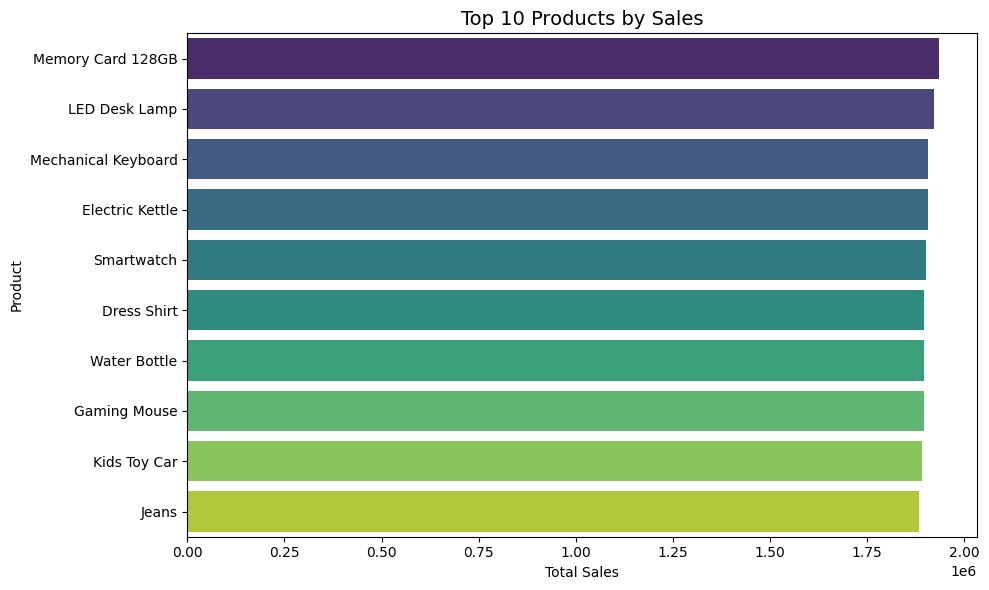

In [29]:
top10_products = (
    df.groupby('ProductName')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_products.values, y=top10_products.index, orient='h', palette='viridis')
plt.title('Top 10 Products by Sales', fontsize=14)
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()